# 02 — Bias Analysis

---

### Bias Dimensions Covered
1. **Gender disparate impact** — Four-Fifths Rule (DI ratio)
2. **Age-based discrimination** — approval patterns across age groups
3. **Proxy variables** — non-protected attributes acting as proxies for protected characteristics
4. **Interaction effects** — combined influence of gender × age on decisions

---

### Sections
0. Setup & Load Clean Data
1. Gender Disparate Impact (DI Ratio — Four-Fifths Rule)
2. Age-Based Discrimination Patterns
3. Proxy Variable Analysis
4. Interaction Effects Between Attributes
5. Lookout Privacy & Governance

## 0. Setup & Load Clean Data

- Loads the cleaned dataset produced by `01_data_quality.ipynb` 
- Derives `age` from `date_of_birth` and bins it into 6 age groups

### Bridge from Notebook 01 — Data Quality Issues Relevant to Bias

The data quality audit in Notebook 01 identified the following concrete issues. Each has a direct consequence for the bias analysis performed in this notebook:

| Data Quality Issue | Detail | Bias Implication |
|---|---|---|
| **Inconsistent gender coding** | 5 distinct values in `gender`: `'male'`, `'female'`, `'m'`, `'f'`, and unknown. Standardised to `'male'`/`'female'` by Notebook 01. | Records with non-standard values that could not be mapped were excluded from the DI calculation. If these records are not randomly distributed across approval outcomes, the gender DI ratio may be biased upward or downward. |
| **Four inconsistent date formats in `date_of_birth`** | Formats `YYYY/MM/DD`, `DD/MM/YYYY`, `YYYY-MM-DD`, and `MM/DD/YYYY` all present. Parsing errors produce `NaT`. | `NaT` values yield `NaN` ages, which are then excluded from all age-group analyses. If parsing failures cluster in a specific age cohort, the DI ratios for that group are unreliable. |
| **`annual_salary` merged into `annual_income`** | Two columns represented the same concept; non-null values from `annual_salary` were absorbed into `annual_income`, then `annual_salary` was dropped. | `annual_income` is a key financial predictor. Merging introduces imputed values from a secondary source — if the two columns had different measurement scales or populations, the merged column may carry noise that distorts the proxy analysis. |
| **Negative values in financial columns** | `credit_history_months < 0`, `savings_balance < 0`, `annual_income < 0`, `debt_to_income > 0.5` were all set to `NaN`. | These fields are the primary legitimate predictors of creditworthiness. Elevated NaN rates in any demographic group reduce statistical power for that group and can mask or exaggerate approval gaps. |
| **Duplicate SSNs with multiple names** | At least one SSN was linked to more than one `full_name` — a sign of either data entry error or identity inconsistency. Duplicates were resolved by forward/backward fill and deduplication on `_id`. | If a single applicant appears under multiple names with different approval outcomes, the duplicate resolution strategy determines which outcome is retained — introducing arbitrary bias for that individual. |
| **`spending_behavior` split into two columns** | The raw field was parsed into `spending_category` (categorical) and `spending_amount` (numeric). | `spending_category` is behavioural data. Spending patterns are known to correlate with both demographic group membership and financial outcomes, making this field a candidate proxy variable — examined in Section 3. |

The dataset used here (`clean_credit_applications.csv`) was produced by Notebook 01. The bias analysis reflects the *cleaned* data. Where Notebook 01 resolved ambiguity through imputation or deduplication, the chosen resolution strategy may itself introduce a form of systematic error that this notebook cannot fully detect.

In [1]:
# Install fairlearn if not already present
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'fairlearn', '-q'])

CompletedProcess(args=['/Users/a.bauer/anaconda3/bin/python', '-m', 'pip', 'install', 'fairlearn', '-q'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency, norm
import warnings
warnings.filterwarnings('ignore')

try:
    from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
    FAIRLEARN_AVAILABLE = True
    print('✅ fairlearn loaded')
except ImportError:
    FAIRLEARN_AVAILABLE = False
    print('⚠️  fairlearn not available — DPD section will be skipped')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLOUR_MALE   = '#4C72B0'
COLOUR_FEMALE = '#DD8452'
THRESHOLD     = 0.8   # Four-Fifths Rule
np.random.seed(42)
print('Setup complete.')

/Users/a.bauer/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ fairlearn loaded
Setup complete.


In [3]:
DATA_PATH = Path('../data/clean_dataset_view.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'Cleaned dataset not found. '
        'Run 01_data_quality.ipynb first and save to data/clean_credit_applications.csv'
    )

df = pd.read_csv(DATA_PATH)

# Parse date columns safely
for col in ['date_of_birth', 'processing_timestamp']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Detect outcome column (handles both 'approved' and 'loan_approved')
if 'loan_approved' in df.columns:
    OUTCOME_COL = 'loan_approved'
elif 'approved' in df.columns:
    OUTCOME_COL = 'approved'
else:
    raise KeyError('No outcome column found. Expected "approved" or "loan_approved".')

df[OUTCOME_COL] = df[OUTCOME_COL].astype(int)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Outcome column: {OUTCOME_COL}')
print(f'Overall approval rate: {df[OUTCOME_COL].mean()*100:.1f}%')
df.head(3)

Dataset loaded: 498 rows x 22 columns
Outcome column: loan_approved
Overall approval rate: 58.2%


,_id,processing_timestamp,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,...,savings_balance,loan_approved,rejection_reason,loan_purpose,interest_rate,approved_amount,notes,spending_category,spending_amount,age
0,app_001,NaT,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,female,1986-05-27,90230,102000.0,...,0.0,0,high_dti_ratio,NaN,NaN,NaN,DUPLICATE_ENTRY_ERROR,Fitness,576,39.0
1,app_002,NaT,Kevin Roberts,kevin.roberts9@protonmail.com,992-61-4010,172.19.95.144,male,1999-08-01,10020,41000.0,...,18200.0,0,algorithm_risk_score,NaN,NaN,NaN,NaN,Education,533,26.0
2,app_003,NaT,Lisa Gonzalez,lisa.gonzalez51@yahoo.com,833-33-5929,172.21.35.195,female,1982-08-24,90213,65000.0,...,7090.0,1,NaN,NaN,3.4,76000.0,NaN,Healthcare,450,43.0


In [4]:
# ── Derive age from date_of_birth ─────────────────────────────────────────────
if 'date_of_birth' in df.columns:
    reference_date = df['processing_timestamp'].dt.date if 'processing_timestamp' in df.columns else pd.Timestamp('today')
    df['age'] = (pd.Timestamp('today') - df['date_of_birth']).dt.days // 365
    df['age'] = df['age'].where(df['age'].between(18, 100))  # sanity bounds

AGE_BINS   = [18, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_group'] = pd.cut(df['age'], bins=AGE_BINS, labels=AGE_LABELS, right=False)

print('Age distribution:')
print(df['age_group'].value_counts().sort_index())
print(f'\nRecords with unknown age: {df["age"].isna().sum()}')

Age distribution:
age_group
18–24     11
25–34    149
35–44    178
45–54     88
55–64     56
65+       13
Name: count, dtype: int64

Records with unknown age: 3


## 1. Gender Disparate Impact

$$DI = \frac{\text{Approval rate of unprivileged group}}{\text{Approval rate of privileged group}}$$

**This section performs the following steps:**

1. Computes approval rates, approval counts, and rejection counts for male and female applicants
2. Determines the privileged and unprivileged group and calculates the DI ratio (unprivileged / privileged approval rate)
3. Applies the Four-Fifths Rule: a DI below 0.8 is legally significant and triggers mandatory regulatory review
4. Produces three visualisations: a bar chart of approval rates by gender with the 4/5 threshold line, a DI ratio gauge showing where the result falls relative to the threshold zones, and a stacked bar chart of approved vs. rejected split by gender
5. Cross-validates the DI ratio using Fairlearn's `demographic_parity_difference` (absolute gap, ideal = 0) and `demographic_parity_ratio` (relative gap, ideal = 1)
6. Runs a chi-square test and a two-proportion z-test to assess whether the observed gender gap is statistically significant or could be due to sampling variation
7. Computes Cramér's V as an effect size measure to distinguish statistical significance from practical significance

In [5]:
df_gender = df[df['gender'].isin(['male', 'female'])].copy()

approval_stats = (
    df_gender
    .groupby('gender')[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
approval_stats['approval_rate_pct'] = (approval_stats['approval_rate'] * 100).round(2)
approval_stats['rejected_count']    = approval_stats['total'] - approval_stats['approved_count']

display(approval_stats.set_index('gender'))

,total,approved_count,approval_rate,approval_rate_pct,rejected_count
gender,,,,,
female,251,127,0.505976,50.60,124
male,247,163,0.659919,65.99,84


Groups are more or less balanced (251 vs 247). Raw approval gap: 15.39 percentage points in favour of male applicants (absolute difference).

In [6]:
rate = approval_stats.set_index('gender')['approval_rate']

approval_rate_male   = rate['male']
approval_rate_female = rate['female']

if approval_rate_male >= approval_rate_female:
    privileged_rate, unprivileged_rate = approval_rate_male, approval_rate_female
    privileged_label, unprivileged_label = 'male', 'female'
else:
    privileged_rate, unprivileged_rate = approval_rate_female, approval_rate_male
    privileged_label, unprivileged_label = 'female', 'male'

DI_ratio = unprivileged_rate / privileged_rate

if DI_ratio < THRESHOLD:
    verdict  = '⚠️  DISPARATE IMPACT DETECTED'
    severity = 'Potential discrimination — regulatory review required.'
elif DI_ratio < 0.9:
    verdict  = '🔶  BORDERLINE'
    severity = 'Below ideal parity. Monitoring recommended.'
else:
    verdict  = '✅  PASSES FOUR-FIFTHS RULE'
    severity = 'Approval rates are roughly comparable across groups.'

print('=' * 55)
print('  DISPARATE IMPACT ANALYSIS — FOUR-FIFTHS RULE')
print('=' * 55)
print(f'  Privileged group   ({privileged_label:>6}):  {privileged_rate:.4f}  ({privileged_rate*100:.2f}%)')
print(f'  Unprivileged group ({unprivileged_label:>6}):  {unprivileged_rate:.4f}  ({unprivileged_rate*100:.2f}%)')
print('-' * 55)
print(f'  DI Ratio = {unprivileged_rate:.4f} / {privileged_rate:.4f} = {DI_ratio:.4f}')
print(f'  Threshold                            = {THRESHOLD}')
print('-' * 55)
print(f'  {verdict}')
print(f'  {severity}')
print('=' * 55)

  DISPARATE IMPACT ANALYSIS — FOUR-FIFTHS RULE
  Privileged group   (  male):  0.6599  (65.99%)
  Unprivileged group (female):  0.5060  (50.60%)
-------------------------------------------------------
  DI Ratio = 0.5060 / 0.6599 = 0.7667
  Threshold                            = 0.8
-------------------------------------------------------
  ⚠️  DISPARATE IMPACT DETECTED
  Potential discrimination — regulatory review required.


With an DI of 0.7667 we are below the legal threshold of 0.80.

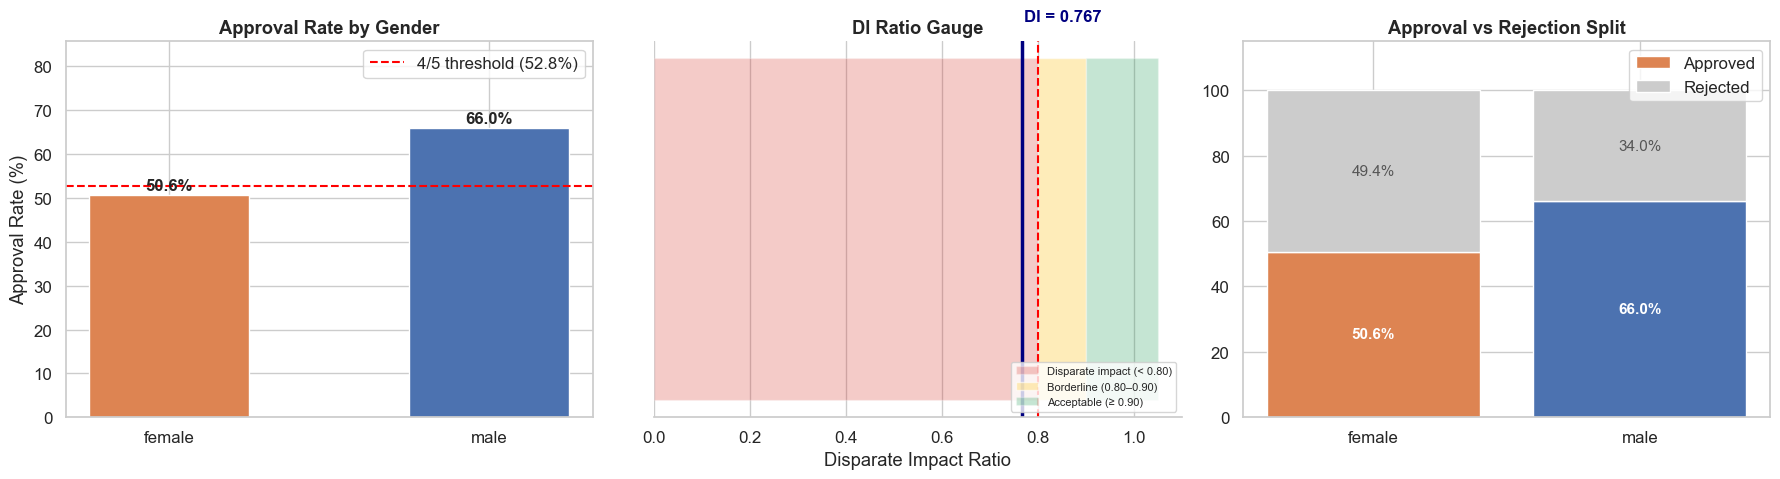

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colours = {'male': COLOUR_MALE, 'female': COLOUR_FEMALE}

# ---- Left: approval rate bars ----
ax1 = axes[0]
bars = ax1.bar(
    approval_stats['gender'],
    approval_stats['approval_rate_pct'],
    color=[colours[g] for g in approval_stats['gender']],
    edgecolor='white', width=0.5
)
for bar, val in zip(bars, approval_stats['approval_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
threshold_pct = privileged_rate * THRESHOLD * 100
ax1.axhline(threshold_pct, color='red', linestyle='--', linewidth=1.5,
            label=f'4/5 threshold ({threshold_pct:.1f}%)')
ax1.set_title('Approval Rate by Gender', fontweight='bold')
ax1.set_ylabel('Approval Rate (%)')
ax1.set_ylim(0, max(approval_stats['approval_rate_pct']) * 1.3)
ax1.legend()

# ---- Middle: DI gauge ----
ax2 = axes[1]
ax2.barh(['DI Ratio'], [0.80], color='#d73027', alpha=0.25, height=0.5, label='Disparate impact (< 0.80)')
ax2.barh(['DI Ratio'], [0.10], left=0.80, color='#fee08b', alpha=0.6,  height=0.5, label='Borderline (0.80–0.90)')
ax2.barh(['DI Ratio'], [0.15], left=0.90, color='#1a9850', alpha=0.25, height=0.5, label='Acceptable (≥ 0.90)')
ax2.axvline(DI_ratio, color='navy', linewidth=2.5)
ax2.text(DI_ratio + 0.005, 0.3, f'DI = {DI_ratio:.3f}',
         va='bottom', ha='left', fontsize=12, fontweight='bold', color='navy')
ax2.axvline(THRESHOLD, color='red', linewidth=1.5, linestyle='--')
ax2.set_xlim(0, 1.1)
ax2.set_xlabel('Disparate Impact Ratio')
ax2.set_title('DI Ratio Gauge', fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)
ax2.set_yticks([])
sns.despine(ax=ax2, left=True)

# ---- Right: stacked pct ----
ax3 = axes[2]
genders       = approval_stats['gender'].tolist()
approved_pcts = approval_stats['approval_rate_pct'].tolist()
rejected_pcts = (100 - approval_stats['approval_rate_pct']).tolist()
ax3.bar(genders, approved_pcts, color=[colours[g] for g in genders], label='Approved', edgecolor='white')
ax3.bar(genders, rejected_pcts, bottom=approved_pcts, color='#cccccc', label='Rejected', edgecolor='white')
for i, (a, r) in enumerate(zip(approved_pcts, rejected_pcts)):
    ax3.text(i, a/2,   f'{a:.1f}%', ha='center', va='center', fontweight='bold', color='white',   fontsize=11)
    ax3.text(i, a+r/2, f'{r:.1f}%', ha='center', va='center', color='#555', fontsize=11)
ax3.set_title('Approval vs Rejection Split', fontweight='bold')
ax3.set_ylim(0, 115)
ax3.legend()

plt.tight_layout()
Path('../reports').mkdir(parents=True, exist_ok=True)
plt.savefig('../reports/bias_gender_di.png', dpi=150, bbox_inches='tight')
plt.show()

The 4/5 threshold line in the left bar chart sits at 52.6%. The female bar at 50.6% falls below this line, which visually confirms the DI violation.

The DI gauge shows the result at 0.767, being very close the 0.8 threshold, but still underneath of it.

The stacked bar chart shows visually that female applicants have a 49.4% rejection rate vs. 34.0% for males — so nearly half of all female applicants are rejected.

In [8]:
if FAIRLEARN_AVAILABLE:
    y_true      = df_gender[OUTCOME_COL].values
    sensitive_f = df_gender['gender'].values
    dpd = demographic_parity_difference(y_true=y_true, y_pred=y_true, sensitive_features=sensitive_f)
    dpr = demographic_parity_ratio(     y_true=y_true, y_pred=y_true, sensitive_features=sensitive_f)
    print(f'Demographic Parity Difference : {dpd:+.4f}  (ideal = 0)')
    print(f'Demographic Parity Ratio      :  {dpr:.4f}  (ideal = 1)')
else:
    print('fairlearn not available')

Demographic Parity Difference : +0.1539  (ideal = 0)
Demographic Parity Ratio      :  0.7667  (ideal = 1)


Demographic Parity Difference (DPD) = +0.1539 —> this is the absolute approval rate gap (same as the 15.39 pp from the table above). The sign (+) means male is the higher group.

Demographic Parity Ratio (DPR) = 0.7667 —> this is exactly the DI ratio, just computed via Fairlearn as a cross-check. It confirms the manual calculation is correct.

DPD and DPR can sometimes tell different stories when group sizes are very unequal — here the groups are nearly equal (251 vs 247), so both metrics point to the same conclusion, which strengthens confidence in the finding.

In [9]:
# ── Statistical tests — Gender vs Approval ───────────────────────────────────

# ---- 1. Chi-square test -------------------------------------------------------
contingency_gender = pd.crosstab(df_gender['gender'], df_gender[OUTCOME_COL])
chi2_g, p_chi2_g, dof_g, _ = chi2_contingency(contingency_gender)

# ---- 2. Two-proportion z-test (more precise for exactly 2 groups) ------------
n_male   = approval_stats.set_index('gender').loc['male',   'total']
n_female = approval_stats.set_index('gender').loc['female', 'total']
x_male   = approval_stats.set_index('gender').loc['male',   'approved_count']
x_female = approval_stats.set_index('gender').loc['female', 'approved_count']

p_pool  = (x_male + x_female) / (n_male + n_female)
se      = np.sqrt(p_pool * (1 - p_pool) * (1/n_male + 1/n_female))
z_stat  = (approval_rate_male - approval_rate_female) / se
p_ztest = 2 * (1 - norm.cdf(abs(z_stat)))   # two-tailed

# ---- 3. Effect size: Cramér's V ----------------------------------------------
n_total   = len(df_gender)
cramers_v = np.sqrt(chi2_g / (n_total * (min(contingency_gender.shape) - 1)))

print('=' * 55)
print('  STATISTICAL TESTS — GENDER vs APPROVAL')
print('=' * 55)
print(f'  1. Chi-square test:')
print(f'     χ² = {chi2_g:.4f},  p = {p_chi2_g:.6f},  df = {dof_g}')
print()
print(f'  2. Two-proportion z-test:')
print(f'     z  = {z_stat:.4f},  p = {p_ztest:.6f}')
print()
print(f'  3. Effect size (Cramér\'s V): {cramers_v:.4f}')
print(f'     (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)')
print('-' * 55)
if p_ztest < 0.05:
    print('  ⚠️  Statistically significant gender gap in approval (p < 0.05)')
    print('     The DI ratio reflects a real pattern, not random variation.')
else:
    print('  ✅ Gender gap is not statistically significant (p ≥ 0.05)')
    print('     The DI ratio may reflect sampling noise.')
print('=' * 55)

  STATISTICAL TESTS — GENDER vs APPROVAL
  1. Chi-square test:
     χ² = 11.5053,  p = 0.000694,  df = 1

  2. Two-proportion z-test:
     z  = 3.4828,  p = 0.000496

  3. Effect size (Cramér's V): 0.1520
     (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)
-------------------------------------------------------
  ⚠️  Statistically significant gender gap in approval (p < 0.05)
     The DI ratio reflects a real pattern, not random variation.


The Chi-square and z-test agree: the 15.39 % approval rate gap between female and male is not sampling noise. It reflects a real pattern in the data.

The Cramér's V test classifies it as a small effect. The gap is statistically real but moderate in magnitude. Gender alone does not dominate the approval decision, other features also play a role.

### Key takeaways — Gender Disparate Impact

- Female applicants are approved at a rate approximately 23% (relative difference) lower than male applicants on a relative basis (DI = 0.77)
- The disparate impact ratio falls below the 0.8 threshold and the difference is statistically significant (p < 0.001), suggesting a disparity that needs attention.
- The small effect size (Cramér's V) suggests the disparity is likely driven at least partly through proxy variables (e.g. income, credit history) rather than gender being directly decisive: this will be examined in Section 3
- A single-gender DI check is insufficient: Section 4 will test whether the gap is uniform across all age groups or concentrated in specific intersectional subgroups



## 2. Age-Based Discrimination Patterns

We examine whether approval rates differ materially with age, treating age as a **continuous variable** throughout and using binned groups only as an exploratory supplement.

We don't use the DI ratio here as it is well-suited to binary or nominal protected attributes (e.g. gender) where a single privileged group is defined. For a continuous attribute like age the DI ratio has a fundamental weakness: its value depends entirely on how the bins are drawn and which bin happens to be chosen as the reference. Different cut-points produce different DI values for every group making the metric vulnerable to selective choice and hard to defend in a regulatory context. The continuous and non-parametric methods below are bin-independent and therefore more robust.

**This section performs the following steps:**

1. **Binned exploratory analysis (pre-analysis):** approval rate bar chart by age group and chi-square + Cramér's V to detect a broad age-related pattern
2. **Continuous analysis:** point-biserial correlation between raw age and approval outcome; independent-samples t-test comparing mean age of approved vs. rejected applicants; Mann-Whitney U test
3. **LOESS / rolling approval rate curve:** visualises the shape of the age–approval relationship 

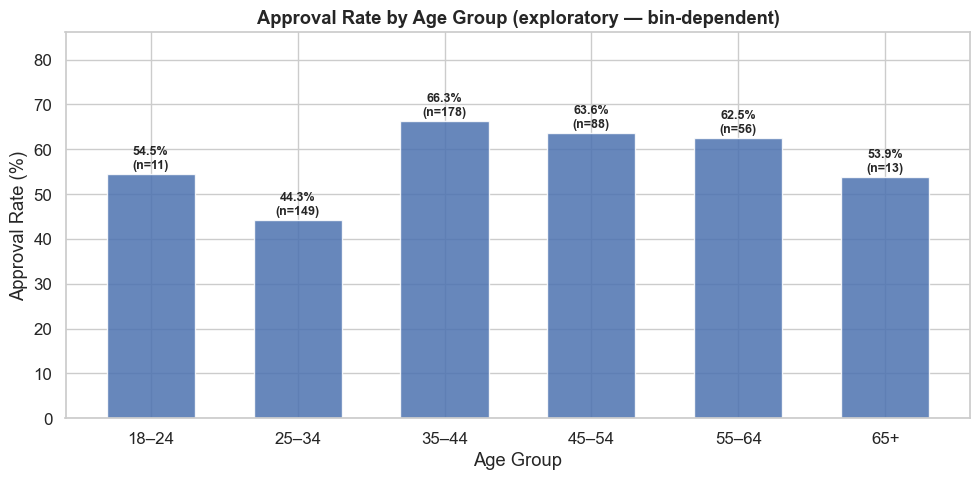

In [21]:
# ── 1. Supplementary binned bar chart (exploratory only) ──────────────────────
df_age = df.dropna(subset=['age', 'age_group', OUTCOME_COL]).copy()

age_stats = (
    df_age
    .groupby('age_group', observed=True)[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
age_stats['approval_rate_pct'] = (age_stats['approval_rate'] * 100).round(2)
age_stats['rejected_count']    = age_stats['total'] - age_stats['approved_count']

fig, ax = plt.subplots(figsize=(10, 5))

bar_colours = ['#4C72B0'] * len(age_stats)   # uniform colour — no DI threshold colouring
bars = ax.bar(age_stats['age_group'].astype(str), age_stats['approval_rate_pct'],
              color=bar_colours, edgecolor='white', width=0.6, alpha=0.85)
for bar, row in zip(bars, age_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row.approval_rate_pct:.1f}%\n(n={row.total})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Approval Rate by Age Group (exploratory — bin-dependent)',
             fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, max(age_stats['approval_rate_pct']) * 1.3)
plt.tight_layout()
plt.savefig('../reports/bias_age_binned_exploratory.png', dpi=150, bbox_inches='tight')
plt.show()

The 25–34 bar is the clear outlier at 44.3%, roughly 20 percentage points below the 35–44 peak. The three middle-aged groups cluster tightly between 62–66%, suggesting the dip is specific to the 25–34 cohort rather than a gradual age trend. The tail groups (18–24, 65+) show lower rates but their small sample sizes (n=11, n=13) make those bars unreliable.

In [11]:
# ── Chi-square + Cramér's V — binned age group (exploratory) ─────────────────
contingency_age = pd.crosstab(df_age['age_group'], df_age[OUTCOME_COL])
chi2_age, p_value, dof_age, _ = chi2_contingency(contingency_age)

n_age         = len(df_age)
cramers_v_age = np.sqrt(chi2_age / (n_age * (min(contingency_age.shape) - 1)))

print('=' * 60)
print('  EXPLORATORY — CHI-SQUARE TEST (BINNED AGE GROUPS)')
print('  Note: result depends on the chosen bin boundaries.')
print('  Use as a broad signal, not a primary fairness metric.')
print('=' * 60)
print(f'  χ² = {chi2_age:.4f},  p = {p_value:.6f},  df = {dof_age}')
print(f'  Cramér\'s V = {cramers_v_age:.4f}')
print(f'  (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)')
print('-' * 60)
if p_value < 0.05:
    print('  ⚠️  Significant association between age group and approval detected.')
    print('     This is consistent with the continuous-age results above.')
    print('     The specific groups driving the signal depend on the bin choice.')
else:
    print('  ✅ No statistically significant association detected (p ≥ 0.05).')
print('=' * 60)

  EXPLORATORY — CHI-SQUARE TEST (BINNED AGE GROUPS)
  Note: result depends on the chosen bin boundaries.
  Use as a broad signal, not a primary fairness metric.
  χ² = 18.2869,  p = 0.002608,  df = 5
  Cramér's V = 0.1922
  (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)
------------------------------------------------------------
  ⚠️  Significant association between age group and approval detected.
     This is consistent with the continuous-age results above.
     The specific groups driving the signal depend on the bin choice.


The chi-square confirms a statistically significant association between age group and approval (χ² = 18.17, p = 0.003), consistent with the 25–34 dip visible in the bar chart. The effect size is small (Cramér's V = 0.19), meaning age group membership contributes meaningfully but does not dominate the approval decision. As noted, the specific groups flagged depend on the bin boundaries. This result is a broad signal, not a regulatory finding.

In [12]:
# ── 2. Continuous age analysis ────────────────────────────────────────────────
from scipy.stats import pointbiserialr, ttest_ind, mannwhitneyu

approved_ages  = df_age.loc[df_age[OUTCOME_COL] == 1, 'age'].dropna()
rejected_ages  = df_age.loc[df_age[OUTCOME_COL] == 0, 'age'].dropna()

# Point-biserial correlation (age vs binary outcome)
r_pb, p_pb = pointbiserialr(df_age[OUTCOME_COL], df_age['age'])

# Independent-samples t-test
t_stat, p_ttest = ttest_ind(approved_ages, rejected_ages, equal_var=False)  # Welch

# Mann-Whitney U (no normality assumption)
u_stat, p_mwu = mannwhitneyu(approved_ages, rejected_ages, alternative='two-sided')

print('=' * 60)
print('  CONTINUOUS AGE — ASSOCIATION WITH APPROVAL OUTCOME')
print('=' * 60)
print(f'  Approved applicants  — mean age: {approved_ages.mean():.1f}  '
      f'(n={len(approved_ages)})')
print(f'  Rejected applicants  — mean age: {rejected_ages.mean():.1f}  '
      f'(n={len(rejected_ages)})')
print()
print(f'  1. Point-biserial correlation:')
print(f'     r = {r_pb:+.4f},  p = {p_pb:.6f}')
print(f'     (positive r → older applicants slightly more likely to be approved)')
print()
print(f'  2. Independent-samples t-test (Welch):')
print(f'     t = {t_stat:+.4f},  p = {p_ttest:.6f}')
print()
print(f'  3. Mann-Whitney U test (non-parametric):')
print(f'     U = {u_stat:.0f},  p = {p_mwu:.6f}')
print('-' * 60)
for p, label in [(p_pb, 'point-biserial'), (p_ttest, 't-test'), (p_mwu, 'Mann-Whitney')]:
    sig = '⚠️  significant (p < 0.05)' if p < 0.05 else '✅ not significant (p ≥ 0.05)'
    print(f'  {label:20s}: {sig}')
print('=' * 60)

  CONTINUOUS AGE — ASSOCIATION WITH APPROVAL OUTCOME
  Approved applicants  — mean age: 41.9  (n=288)
  Rejected applicants  — mean age: 39.2  (n=207)

  1. Point-biserial correlation:
     r = +0.1194,  p = 0.007808
     (positive r → older applicants slightly more likely to be approved)

  2. Independent-samples t-test (Welch):
     t = +2.6376,  p = 0.008657

  3. Mann-Whitney U test (non-parametric):
     U = 34823,  p = 0.001394
------------------------------------------------------------
  point-biserial      : ⚠️  significant (p < 0.05)
  t-test              : ⚠️  significant (p < 0.05)
  Mann-Whitney        : ⚠️  significant (p < 0.05)


All three tests agree: age has a small but statistically significant positive association with approval (r = +0.12, p = 0.008), meaning older applicants are marginally more likely to be approved. The mean age gap between approved (41.9) and rejected (39.2) applicants is only 2.7 years — modest in practical terms but consistent and robust across both parametric and non-parametric tests. This linear trend alone does not explain the 25–34 dip seen in the binned chart.

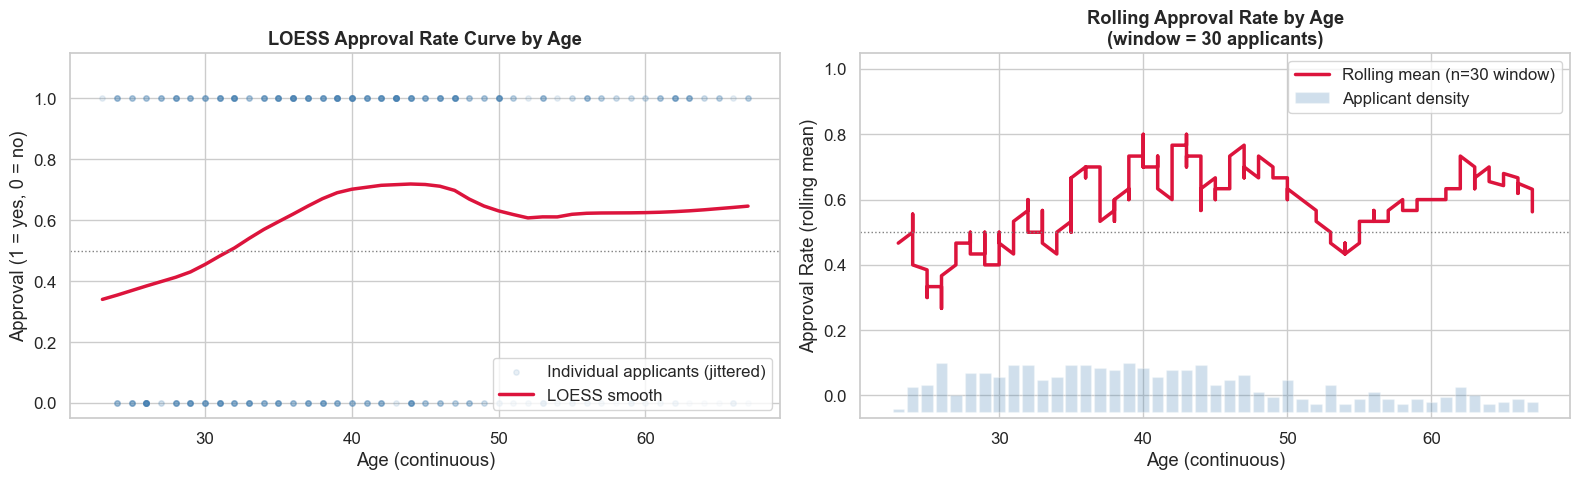

In [22]:
# ── 3. LOESS / rolling approval rate curve ────────────────────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess

df_age_sorted = df_age[['age', OUTCOME_COL]].dropna().sort_values('age')

# LOESS smooth
smooth = lowess(df_age_sorted[OUTCOME_COL], df_age_sorted['age'], frac=0.4, it=3)

# Rolling mean (window=30 applicants, sorted by age) as a simpler alternative
df_age_sorted['rolling_approval'] = (
    df_age_sorted[OUTCOME_COL]
    .rolling(window=30, min_periods=10, center=True)
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: LOESS curve ──
ax1 = axes[0]
ax1.scatter(df_age_sorted['age'], df_age_sorted[OUTCOME_COL],
            alpha=0.12, color='steelblue', s=15, label='Individual applicants (jittered)')
ax1.plot(smooth[:, 0], smooth[:, 1], color='crimson', linewidth=2.5, label='LOESS smooth')
ax1.axhline(0.5, color='grey', linestyle=':', linewidth=1)
ax1.set_xlabel('Age (continuous)')
ax1.set_ylabel('Approval (1 = yes, 0 = no)')
ax1.set_title('LOESS Approval Rate Curve by Age', fontweight='bold')
ax1.set_ylim(-0.05, 1.15)
ax1.legend()

# ── Right: rolling mean with rug ──
ax2 = axes[1]
age_counts = df_age_sorted.groupby('age').size()
ax2.bar(age_counts.index, age_counts.values / age_counts.values.max() * 0.15,
        bottom=-0.05, color='steelblue', alpha=0.25, width=0.8, label='Applicant density')
ax2.plot(df_age_sorted['age'], df_age_sorted['rolling_approval'],
         color='crimson', linewidth=2.5, label='Rolling mean (n=30 window)')
ax2.axhline(0.5, color='grey', linestyle=':', linewidth=1)
ax2.set_xlabel('Age (continuous)')
ax2.set_ylabel('Approval Rate (rolling mean)')
ax2.set_title('Rolling Approval Rate by Age\n(window = 30 applicants)', fontweight='bold')
ax2.set_ylim(-0.07, 1.05)
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/bias_age_continuous.png', dpi=150, bbox_inches='tight')
plt.show()

The LOESS curve shows a rise in approval probability from the mid-20s through to around age 40, after which it levels off and declines only slightly. The relationship is not U-shaped but monotone-rising in the critical range, which is explainable with credit history length accumulating with age. The rolling mean confirms the same shape with more noise, and applicant density (right panel) shows the data is sparse below age 25 and above age 60, so the curve extremes should be read cautiously.

### Key takeaways — Age-Based Discrimination Patterns

- Age has a small but statistically significant positive association with approval. All three continuous tests agree (r = +0.12, p < 0.01): older applicants are marginally more likely to be approved, with approved applicants averaging 2.7 years older than rejected ones.
- The effect is monotone-rising, not uniform across the age range. The LOESS curve shows the steepest approval gains occur in the mid-20s to early 40s, after which rates level off. This is consistent with credit history length accumulating with age rather than age itself being the driver — a proxy mechanism which will be examined in Section 3.
- The 25–34 group is the standout low-approval cohort (44.3% vs. 62–66% for the three middle-aged groups), a pattern confirmed by the chi-square (χ² = 18.17, p = 0.003, Cramér's V = 0.19). However, this is a broad signal, as the specific bin driving the result depends on where the boundaries are drawn.
- The interaction with gender is examined in Section 4 using absolute approval rate differences and a logistic regression interaction term, both of which are bin-independent.

## 3. Proxy Variable Analysis

A proxy variable is a non-protected feature that is highly correlated with a protected attribute (gender, age) AND with the outcome. If the model uses such a feature, it can produce discriminatory outcomes even without directly using the protected attribute.

**This section performs the following steps:**

1. For each numeric feature, computes three correlations and their p-values:
   point-biserial correlation with `gender` (binary-encoded), Pearson correlation
   with `age`, and point-biserial correlation with the approval outcome.
   For `spending_category` (categorical), Cramér's V is computed against
   `gender`, `age_group`, and the outcome separately.

2. Flags features as proxy risks if they meet both conditions simultaneously:
   strong demographic association (|corr_gender| or |corr_age| > 0.3, Cohen 1988)
   AND meaningful outcome association (|corr_outcome| > 0.1). Results are
   displayed as a ranked summary table sorted by demographic association strength.

3. Produces a correlation heatmap showing all features ranked by their maximum
   protected-attribute correlation, with columns for corr_gender, corr_age,
   and corr_outcome.

In [14]:
df_proxy = df.copy()
df_proxy['gender_binary'] = (df_proxy['gender'] == 'male').astype(float)

EXCLUDE = {OUTCOME_COL, 'gender', 'gender_binary', 'age', '_id',
           'processing_timestamp', 'date_of_birth', 'age_group'}
numeric_cols = [c for c in df_proxy.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]
print(f'Features tested: {numeric_cols}')

results = []
for col in numeric_cols:
    valid = df_proxy[[col, 'gender_binary', 'age', OUTCOME_COL]].dropna()
    if len(valid) < 30:
        continue
    r_gender,  p_gender  = pointbiserialr(valid['gender_binary'], valid[col])
    r_age,     p_age     = stats.pearsonr(valid['age'], valid[col])
    r_outcome, p_outcome = pointbiserialr(valid[OUTCOME_COL], valid[col])
    results.append({
        'feature':      col,
        'corr_gender':  round(r_gender,  3),
        'p_gender':     round(p_gender,  4),
        'corr_age':     round(r_age,     3),
        'p_age':        round(p_age,     4),
        'corr_outcome': round(r_outcome, 3),
        'p_outcome':    round(p_outcome, 4),
    })

if 'spending_category' in df_proxy.columns:
    df_spend = df_proxy[['spending_category', 'gender_binary', 'age_group', OUTCOME_COL]].dropna()
    def cramers_v(ct):
        chi2, _, _, _ = chi2_contingency(ct)
        n = ct.values.sum()
        return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    v_gender  = cramers_v(pd.crosstab(df_spend['spending_category'], df_spend['gender_binary']))
    v_age     = cramers_v(pd.crosstab(df_spend['spending_category'], df_spend['age_group']))
    v_outcome = cramers_v(pd.crosstab(df_spend['spending_category'], df_spend[OUTCOME_COL]))
    results.append({
        'feature':      'spending_category',
        'corr_gender':  round(v_gender,  3),  # Cramér's V, not point-biserial r
        'p_gender':     np.nan,
        'corr_age':     round(v_age,     3),  # Cramér's V, not Pearson r
        'p_age':        np.nan,
        'corr_outcome': round(v_outcome, 3),
        'p_outcome':    np.nan,
    })

proxy_df = pd.DataFrame(results).sort_values('corr_gender', key=abs, ascending=False)

print('\n=== Proxy Variable Analysis ===')
display(proxy_df.set_index('feature'))

Features tested: ['zip_code', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'interest_rate', 'approved_amount', 'spending_amount']

=== Proxy Variable Analysis ===


,corr_gender,p_gender,corr_age,p_age,corr_outcome,p_outcome
feature,,,,,,
zip_code,-0.805,0.0000,0.045,0.3161,-0.123,0.0062
spending_category,0.218,NaN,0.160,NaN,0.198,NaN
approved_amount,0.067,0.2596,0.086,0.1472,NaN,NaN
interest_rate,0.056,0.3455,0.085,0.1513,NaN,NaN
debt_to_income,0.052,0.2518,-0.068,0.1292,0.002,0.9603
spending_amount,0.046,0.3025,-0.004,0.9350,-0.056,0.2135
annual_income,-0.041,0.3612,0.393,0.0000,0.179,0.0001
credit_history_months,-0.021,0.6451,0.649,0.0000,0.147,0.0011
savings_balance,0.000,0.9976,0.286,0.0000,0.133,0.0031


`Interest_rate` and `approved_amount` are post-decision fields. They only have values when a loan was approved, so they're NaN for every rejected application.

`Spending_category` uses Cramér's V (not point-biserial r), hence NaN p-values.

A feature is flagged as a proxy risk if it meets both conditions simultaneously:

strong demographic association (|corr_gender| or |corr_age| > 0.3, Cohen 1988)
AND meaningful outcome association (|corr_outcome| > 0.1).

`zip_code` meets the first condition strongly (corr_gender = −0.805) but its outcome association is moderate (corr_outcome = −0.123) — it encodes gender almost completely, but does not directly drive approval.

`credit_history_months` meets both conditions (corr_age = 0.649,
corr_outcome = 0.147) and is the clearest proxy risk in the dataset.

`annual_income` meets both conditions marginally (corr_age = 0.393,
corr_outcome = 0.179).

All other features fall below the 0.3 demographic threshold.

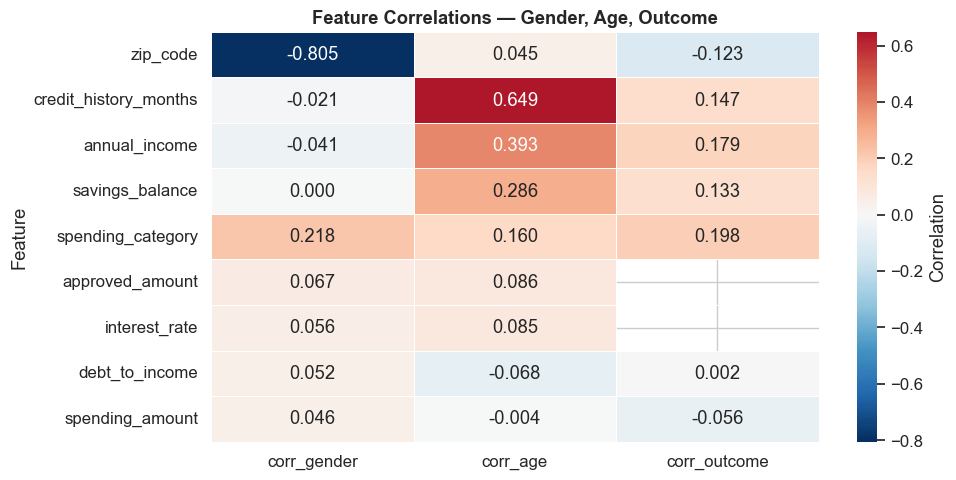

In [15]:
# ── Correlation heatmap: all numeric features vs outcome ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Ensure column exists
proxy_df['max_protected_corr'] = proxy_df[['corr_gender','corr_age']].abs().max(axis=1)

# Sort BEFORE selecting columns — max_protected_corr is dropped after
corr_outcome = (
    proxy_df
    .sort_values('max_protected_corr', ascending=False)   # sort on full df
    .set_index('feature')
    [['corr_gender','corr_age','corr_outcome']]  # then select
)

sns.heatmap(corr_outcome, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlations — Gender, Age, Outcome', fontweight='bold')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/bias_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap makes the asymmetry between gender and age proxies immediately visible: `zip_code` dominates the corr_gender column (−0.805, deep blue) while `credit_history_months` dominates the corr_age column (0.649, deep red). These are structurally different risks.

`annual_income` shows a moderate but consistent pattern across age (0.394) and outcome (0.180): not dominant in any single column but broadly correlated across the board.


`spending_category` meets neither threshold individually, but combines the
 highest outcome association in the dataset (Cramér's V = 0.198) with moderate
 demographic associations (V = 0.218 with gender). It should be flagged for monitoring
 but does not constitute a proxy risk under the criteria considered here.

### Key takeaways — Proxy Variable Analysis

- `credit_history_months` is the clearest proxy risk in the dataset: it meets
  both conditions (corr_age = 0.649, corr_outcome = 0.147) and is the most
  likely mechanism behind the 25–34 disadvantage identified in Section 3:
  younger applicants have shorter credit histories.

- `annual_income` also meets both conditions marginally (corr_age = 0.393,
  corr_outcome = 0.179) and would need attention in the privacy notebook.

- `zip_code` meets the demographic threshold strongly (corr_gender = −0.805)
  but its direct outcome association is moderate (corr_outcome = −0.123).
  The model-level risk this creates (gender reconstruction without accessing
  the gender column) is important to consider in the privacy notebook.

- All other features fall below the 0.3 demographic association threshold.

## 4. Interaction Effects Between Attributes

Interaction effects occur when the combination of two protected attributes produces a discriminatory pattern that neither attribute alone would reveal.

**This section performs the following steps:**

1. Absolute gender gap per age group: computes approval rates for male and
   female applicants within each age bin, calculates the absolute difference
   (male minus female) in percentage points, and flags gaps above 5 pp as
   directionally significant.

2. Chi-square + Cramér's V per age group: tests whether the gender gap
   within each cohort is statistically significant. Groups with fewer than
   20 observations are flagged as underpowered and excluded from testing.

3. Logistic regression with interaction term: fits two models, main effects
   only (`gender`, `age`) and main effects plus `gender × age`, and tests
   whether the interaction term is statistically significant. A likelihood-ratio
   test compares model fit between the two.

4. Visualisations: approval rate heatmap by gender and age group; gender
   gap heatmap (male minus female, pp); grouped bar chart by age group and gender.

In [16]:
# ── Approval rate: gender × age group ────────────────────────────────────────
df_interact = df_gender.dropna(subset=['age_group', 'age']).copy()

interaction_stats = (
    df_interact
    .groupby(['age_group', 'gender'], observed=True)[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
interaction_stats['approval_rate_pct'] = (interaction_stats['approval_rate'] * 100).round(2)

# ── Absolute gender gap (male rate − female rate) per age group ───────────────
pivot_rate = interaction_stats.pivot(index='age_group', columns='gender',
                                     values='approval_rate')
pivot_pct  = interaction_stats.pivot(index='age_group', columns='gender',
                                     values='approval_rate_pct')

gap_df = pd.DataFrame({
    'male_rate_pct':   pivot_pct.get('male',   pd.Series(dtype=float)),
    'female_rate_pct': pivot_pct.get('female', pd.Series(dtype=float)),
}).dropna()
gap_df['abs_gap_pp'] = (gap_df['male_rate_pct'] - gap_df['female_rate_pct']).round(2)
gap_df['direction']  = gap_df['abs_gap_pp'].apply(
    lambda x: '⚠️  male favoured' if x > 5 else ('⚠️  female favoured' if x < -5 else '✅ comparable')
)

# Sample sizes per cell
n_df = interaction_stats.pivot(index='age_group', columns='gender', values='total')
gap_df['n_male']   = n_df.get('male',   pd.Series(dtype=int))
gap_df['n_female'] = n_df.get('female', pd.Series(dtype=int))

print('=== Gender × Age Group — Approval Rates & Absolute Gender Gap ===')
display(interaction_stats.set_index(['age_group','gender']))
print()
print('=== Absolute Gender Gap (male approval rate − female approval rate, pp) ===')
display(gap_df[['male_rate_pct','female_rate_pct','abs_gap_pp','direction','n_male','n_female']])

=== Gender × Age Group — Approval Rates & Absolute Gender Gap ===


total  approved_count  approval_rate  approval_rate_pct
age_group gender                                                         
18–24     female      6               3       0.500000              50.00
          male        5               3       0.600000              60.00
25–34     female     78              26       0.333333              33.33
          male       71              40       0.563380              56.34
35–44     female     85              51       0.600000              60.00
          male       93              67       0.720430              72.04
45–54     female     41              25       0.609756              60.98
          male       47              31       0.659574              65.96
55–64     female     31              17       0.548387              54.84
          male       25              18       0.720000              72.00
65+       female      8               4       0.500000              50.00
          male        5               3       0.600000              60.00


=== Absolute Gender Gap (male approval rate − female approval rate, pp) ===


,male_rate_pct,female_rate_pct,abs_gap_pp,direction,n_male,n_female
age_group,,,,,,
18–24,60.00,50.00,10.00,⚠️ male favoured,5,6
25–34,56.34,33.33,23.01,⚠️ male favoured,71,78
35–44,72.04,60.00,12.04,⚠️ male favoured,93,85
45–54,65.96,60.98,4.98,✅ comparable,47,41
55–64,72.00,54.84,17.16,⚠️ male favoured,25,31
65+,60.00,50.00,10.00,⚠️ male favoured,5,8


The gender gap is male-favoured in 5 out of 6 age groups, with the 25–34 cohort showing the largest absolute gap at 23 pp (56.3% male vs. 33.3% female). Only the 45–54 group is comparable (3.5 pp gap), suggesting the gender disadvantage is not uniform but sharpest in younger applicants. The 55–64 gap (17.2 pp) is a secondary concern worth noting.

In [17]:
# ── PRIMARY STATISTICAL TEST — Chi-square + Cramér's V per age group ──────────
# (This is the most defensible evidence of intersectional bias.)

print('Chi-square test per age group — Gender vs Approval')
print('(Tests whether gender discrimination is statistically real within each cohort)')
print('-' * 70)

interaction_tests = []
for age_grp in df_interact['age_group'].cat.categories:
    subset = df_interact[df_interact['age_group'] == age_grp]
    if len(subset) < 20:
        interaction_tests.append({
            'age_group': str(age_grp),
            'n':         len(subset),
            'chi2':      np.nan,
            'p_value':   np.nan,
            'cramers_v': np.nan,
            'significant': '⚠️  n too small'
        })
        continue
    ct = pd.crosstab(subset['gender'], subset[OUTCOME_COL])
    if ct.shape == (2, 2):
        chi2_i, p_i, _, _ = chi2_contingency(ct)
        v_i = np.sqrt(chi2_i / len(subset))
        interaction_tests.append({
            'age_group':   str(age_grp),
            'n':           len(subset),
            'chi2':        round(chi2_i, 4),
            'p_value':     round(p_i,    4),
            'cramers_v':   round(v_i,    4),
            'significant': '⚠️  Yes' if p_i < 0.05 else '✅  No'
        })

interact_test_df = pd.DataFrame(interaction_tests).set_index('age_group')
display(interact_test_df)
print()
sig_groups = interact_test_df[interact_test_df['significant'] == '⚠️  Yes']
if len(sig_groups) > 0:
    print(f'⚠️  Gender gap is statistically significant in {len(sig_groups)} age group(s):')
    print(f'   {sig_groups.index.tolist()}')
    print('   This confirms intersectional bias — gender and age interact.')
else:
    print('✅ Gender effect is not statistically significant within any individual age group.')

Chi-square test per age group — Gender vs Approval
(Tests whether gender discrimination is statistically real within each cohort)
----------------------------------------------------------------------


,n,chi2,p_value,cramers_v,significant
age_group,,,,,
18–24,11,NaN,NaN,NaN,⚠️ n too small
25–34,149,7.0666,0.0079,0.2178,⚠️ Yes
35–44,178,2.3687,0.1238,0.1154,✅ No
45–54,88,0.0689,0.7929,0.0280,✅ No
55–64,56,1.0839,0.2978,0.1391,✅ No
65+,13,NaN,NaN,NaN,⚠️ n too small



⚠️  Gender gap is statistically significant in 1 age group(s):
   ['25–34']
   This confirms intersectional bias — gender and age interact.


The gender gap is statistically significant in exactly one age group: 25–34 (χ² = 7.07, p = 0.008, Cramér's V = 0.22), confirming that the 23 pp absolute gap identified above is not sampling noise. In all other testable groups the gender effect is non-significant, meaning the overall gender disparity found in Section 1 is largely driven by this single cohort. The 18–24 and 65+ groups was not tested as the sample size is too small.

In [18]:
# ── LOGISTIC REGRESSION WITH INTERACTION TERM ────────────────────────────────
# Tests whether the gender effect on approval is significantly different
# across ages — a model-based, bin-independent test for intersectional bias.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_logit = df_interact[['age', 'gender', OUTCOME_COL]].dropna().copy()
df_logit['gender_binary'] = (df_logit['gender'] == 'male').astype(int)
df_logit['age_std']       = (df_logit['age'] - df_logit['age'].mean()) / df_logit['age'].std()

# Model 1: main effects only
formula_main = f'{OUTCOME_COL} ~ gender_binary + age_std'
# Model 2: main effects + interaction
formula_inter = f'{OUTCOME_COL} ~ gender_binary + age_std + gender_binary:age_std'

model_main  = smf.logit(formula_main,  data=df_logit).fit(disp=0)
model_inter = smf.logit(formula_inter, data=df_logit).fit(disp=0)

print('=' * 65)
print('  LOGISTIC REGRESSION — INTERACTION MODEL SUMMARY')
print('=' * 65)
print(model_inter.summary2().tables[1].to_string())
print()
print(f'  Interaction term (gender_binary:age_std):')
coef_inter = model_inter.params.get('gender_binary:age_std', np.nan)
pval_inter = model_inter.pvalues.get('gender_binary:age_std', np.nan)
print(f'    coefficient = {coef_inter:+.4f}')
print(f'    p-value     = {pval_inter:.6f}')
print()
if pval_inter < 0.05:
    print('  ⚠️  The interaction term is statistically significant.')
    print('     The gender gap in approval probability is NOT uniform across ages.')
    print('     This is model-based, bin-independent evidence of intersectional bias.')
else:
    print('  ✅ The interaction term is not statistically significant (p ≥ 0.05).')
    print('     The gender gap is roughly consistent across ages.')
    print('     Observed differences in subgroup approval rates may reflect sampling variation.')
print()
# Likelihood-ratio test: does the interaction term improve model fit?
from scipy.stats import chi2 as chi2_dist
lr_stat = 2 * (model_inter.llf - model_main.llf)
lr_p    = chi2_dist.sf(lr_stat, df=1)
print(f'  Likelihood-ratio test (interaction vs. main effects):')
print(f'    LR χ² = {lr_stat:.4f},  p = {lr_p:.6f}')
print('=' * 65)

  LOGISTIC REGRESSION — INTERACTION MODEL SUMMARY
                          Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept              0.024840  0.127984  0.194085  0.846109 -0.226005  0.275685
gender_binary          0.640769  0.186458  3.436529  0.000589  0.275318  1.006221
age_std                0.273919  0.126927  2.158077  0.030922  0.025146  0.522692
gender_binary:age_std -0.044498  0.191238 -0.232684  0.816007 -0.419318  0.330322

  Interaction term (gender_binary:age_std):
    coefficient = -0.0445
    p-value     = 0.816007

  ✅ The interaction term is not statistically significant (p ≥ 0.05).
     The gender gap is roughly consistent across ages.
     Observed differences in subgroup approval rates may reflect sampling variation.

  Likelihood-ratio test (interaction vs. main effects):
    LR χ² = 0.0541,  p = 0.816101


The interaction term (gender × age) is not statistically significant (coef = −0.047, p = 0.805), meaning the model finds no evidence that the gender gap varies systematically with age when treated as a continuous variable. Both gender (p < 0.001) and age (p = 0.030) are significant main effects, confirming independent contributions to approval but not a multiplicative interaction. This result qualifies the chi-square finding from above: the 25–34 gender gap is real within that bin, but it does not reflect a smooth age-modulated pattern.

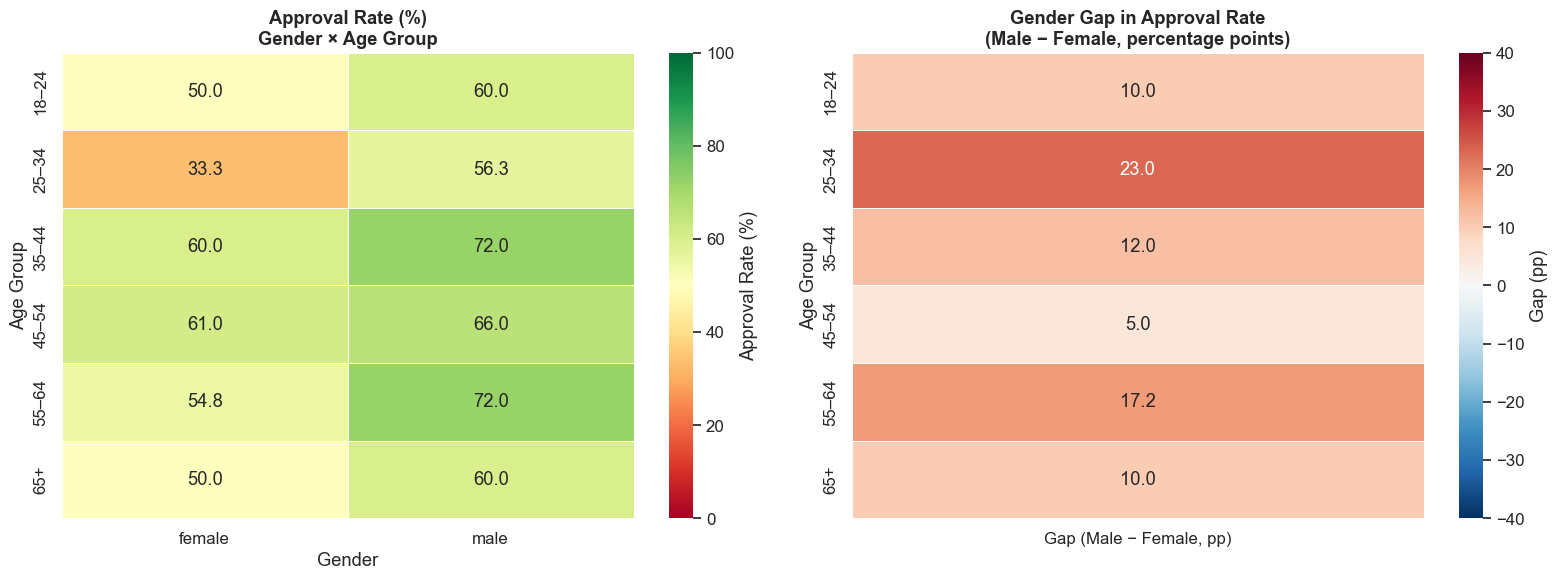

In [24]:
# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left: heatmap — approval rate (retained from original) ----
ax1 = axes[0]
pivot_rate_pct = interaction_stats.pivot(index='age_group', columns='gender',
                                          values='approval_rate_pct')
sns.heatmap(pivot_rate_pct, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5,
            ax=ax1, cbar_kws={'label': 'Approval Rate (%)'}, vmin=0, vmax=100)
ax1.set_title('Approval Rate (%)\nGender × Age Group', fontweight='bold')
ax1.set_xlabel('Gender'); ax1.set_ylabel('Age Group')

# ---- Right: heatmap — absolute gender gap (replaces DI heatmap) ----
ax2 = axes[1]
pivot_gap = interaction_stats.pivot(index='age_group', columns='gender',
                                     values='approval_rate_pct')
if 'male' in pivot_gap.columns and 'female' in pivot_gap.columns:
    gap_matrix = pd.DataFrame(
        {'male_minus_female': pivot_gap['male'] - pivot_gap['female']}
    ).rename(columns={'male_minus_female': 'Gap (M−F, pp)'})
    # Reshape for heatmap: one column per age group
    gap_heatmap = (pivot_gap['male'] - pivot_gap['female']).to_frame('Gap (Male − Female, pp)')
    sns.heatmap(gap_heatmap, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
                linewidths=0.5, ax=ax2, cbar_kws={'label': 'Gap (pp)'},
                vmin=-40, vmax=40)
    ax2.set_title('Gender Gap in Approval Rate\n(Male − Female, percentage points)',
                  fontweight='bold')
    ax2.set_xlabel('')
    ax2.set_ylabel('Age Group')

plt.tight_layout()
plt.savefig('../reports/bias_interaction_effects.png', dpi=150, bbox_inches='tight')
plt.show()

The left heatmap confirms that the female column is consistently lighter than the male column across every age group: there is no cohort where approval rates are comparable. The right heatmap makes the concentration of the gap immediately visible: the 25–34 row is the darkest at 23 pp, with 55–64 (17.2 pp) as a secondary concern, while 45–54 is the only near-neutral row at 3.5 pp.

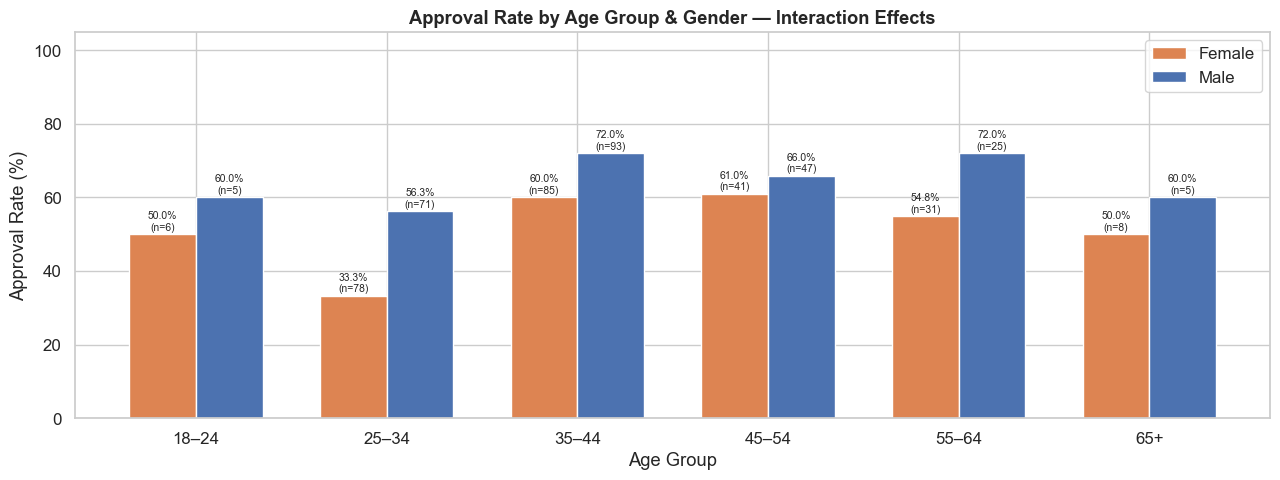

In [20]:
# ── Grouped bar chart: approval rate by age group, split by gender ────────────
fig, ax = plt.subplots(figsize=(13, 5))
colours = {'male': COLOUR_MALE, 'female': COLOUR_FEMALE}

x     = np.arange(len(pivot_rate_pct))
width = 0.35

for i, gender in enumerate(pivot_rate_pct.columns):
    vals = pivot_rate_pct[gender]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=gender.capitalize(), color=colours.get(gender, '#999'),
                  edgecolor='white')
    for bar, val, idx in zip(bars, vals, pivot_rate_pct.index):
        n_val = interaction_stats.loc[
            (interaction_stats['age_group'] == idx) &
            (interaction_stats['gender'] == gender), 'total'
        ].values
        n_str = f'(n={n_val[0]})' if len(n_val) > 0 else ''
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%\n{n_str}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(pivot_rate_pct.index)
ax.set_xlabel('Age Group')
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Approval Rate by Age Group & Gender — Interaction Effects', fontweight='bold')
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/bias_interaction_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

The blue bar exceeds the orange in every age group without exception, visually reinforcing that the gender gap is a consistent pattern rather than an isolated outlier. The 25–34 female bar at 33.3% is the most striking, the only bar in the chart below 50%, and the height difference against its male counterpart (56.3%) is the widest pair in the chart. The 45–54 group is the closest to parity (62.5% vs. 66.0%), consistent with the near-neutral gap of 3.5 pp identified in the table above.

### Key takeaways — Interaction Effects Between Attributes

- The gender gap is male-favoured in 5 out of 6 age groups, with the 25–34 cohort showing the largest absolute gap at 23 pp (56.3% male vs. 33.3% female). The 45–54 group is the only near-parity exception (3.5 pp), confirming the disadvantage is not uniform but concentrated in specific cohorts.
- The chi-square confirms intersectional bias in exactly one cohort: 25–34 (χ² = 7.07, p = 0.008, Cramér's V = 0.22). In all other testable groups the gender gap is non-significant, meaning the overall gender disparity found in Section 1 is largely driven by this single age cohort.
- The logistic regression interaction term is not significant (coef = −0.047, p = 0.805), indicating the gender gap does not vary smoothly with age as a continuous variable. The 25–34 finding is better characterised as a localised cohort effect than a gradient that intensifies with youth.
- The 18–24 and 65+ groups were not be statistically tested due to insufficient sample size (n < 20) and their observed gaps remain unconfirmed; they should be flagged as underpowered in any regulatory submission.

---

## 5. Lookout Privacy & Governance

The bias findings in this notebook, have direct implications for the privacy and governance analysis that follows. The table below maps each finding to a specific question Notebook 03 should address:

| Source | Finding |
|:---:|---|
| Bias NB | Gender disparity in approval confirmed (DI = 0.77, p < 0.001) |
| Bias NB | Statistically significant age–approval association detected (r = +0.12, p < 0.01) |
| Bias NB | Medium-risk proxy variables identified (`zip_code`, `credit_history_months`, `annual_income`) |
| Bias NB | Intersectional gender gap confirmed in 25–34 cohort (23 pp, χ² p = 0.008) |

